In [1]:
!pip install nlpaug nltk pandas scikit-learn
!pip install transformers datasets torch evaluate
!pip install wordcloud
!pip install accelerate -U

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.5/410.5 kB 11.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.1/75.1 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 512.3/512.3 kB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.0/201.0 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.3/150.3 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.9/193.9 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 77.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.4/242.4 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 221.6/221.6 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 377.3/377.3 kB 33.3 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    F

# Imports

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import html
import nlpaug.augmenter.word as naw
from nltk.stem import WordNetLemmatizer
import string
import nltk
from wordcloud import WordCloud
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix,roc_auc_score,roc_curve
from collections import Counter

In [4]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\acer\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\acer\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

# Loading Dataset

In [42]:
dataset=pd.read_csv("hate-speech-and-offensive-language.csv")
dataset

,count,hate_speech,offensive_language,neither,class,tweet
0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...
...,...,...,...,...,...,...
24778,3,0,2,1,1,you's a muthaf***in lie &#8220;@LifeAsKing: @2...
24779,3,0,1,2,2,"you've gone and broke the wrong heart baby, an..."
24780,3,0,3,0,1,young buck wanna eat!!.. dat nigguh like I ain...
24781,6,0,6,0,1,youu got wild bitches tellin you lies


# EDA

In [43]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24783 entries, 0 to 24782
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   count               24783 non-null  int64 
 1   hate_speech         24783 non-null  int64 
 2   offensive_language  24783 non-null  int64 
 3   neither             24783 non-null  int64 
 4   class               24783 non-null  int64 
 5   tweet               24783 non-null  object
dtypes: int64(5), object(1)
memory usage: 1.1+ MB


In [44]:
dataset.describe()

,count,hate_speech,offensive_language,neither,class
count,24783.000000,24783.000000,24783.000000,24783.000000,24783.000000
mean,3.243473,0.280515,2.413711,0.549247,1.110277
std,0.883060,0.631851,1.399459,1.113299,0.462089
min,3.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,0.000000,2.000000,0.000000,1.000000
50%,3.000000,0.000000,3.000000,0.000000,1.000000
75%,3.000000,0.000000,3.000000,0.000000,1.000000
max,9.000000,7.000000,9.000000,9.000000,2.000000


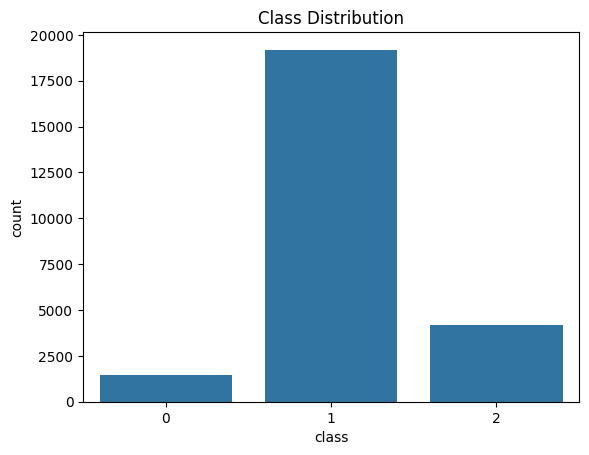

class
1    19190
2     4163
0     1430
Name: count, dtype: int64

In [45]:
# Analyzing the orginal class distribution
sns.countplot(data=dataset, x="class")
plt.title("Class Distribution")
plt.show()

dataset['class'].value_counts()

In [46]:
# Mapping 0 and 1 to 1 (Toxic) and 2 to 0 (Non-Toxic)
dataset['Toxicity'] = dataset['class'].apply(lambda x: 0 if x ==2 else 1)
columns_to_drop = ['count', 'hate_speech', 'offensive_language', 'neither', 'class']
df = dataset.drop(columns=columns_to_drop, axis=1)
print(df.head())

                                               tweet  Toxicity
0  !!! RT @mayasolovely: As a woman you shouldn't...         0
1  !!!!! RT @mleew17: boy dats cold...tyga dwn ba...         1
2  !!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...         1
3  !!!!!!!!! RT @C_G_Anderson: @viva_based she lo...         1
4  !!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...         1


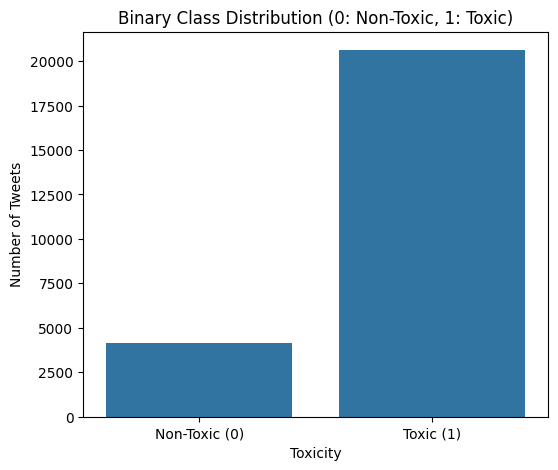

In [47]:
# Class Distribution after Binary Mapping
plt.figure(figsize=(6, 5))
sns.countplot(x='Toxicity', data=df)
plt.title('Binary Class Distribution (0: Non-Toxic, 1: Toxic)')
plt.xticks([0, 1], ['Non-Toxic (0)', 'Toxic (1)'])
plt.ylabel('Number of Tweets')
plt.show()

In [48]:
def light_clean_noise(text):
    text = str(text) # To handle non string inputs
    text = html.unescape(text) # Fix HTML encoding (e.g., change &amp; back to &)
    text = text.lower()  # Lowercasing
    text = re.sub(r'https?://\S+|www\.\S+', '', text) # Remove URLs
    text = re.sub(r'@\w+', '', text) #Remove User Mentions
    text = re.sub(r'#', '', text) # Remove Hastag symbol
    text = re.sub(r'\s+', ' ', text).strip() #Remove Extra Whitespace, newlines, and tabs
    text = re.sub(r'\brt\b', '', text, flags=re.IGNORECASE) # Remove rt  markers
    return text

df['light_cleaned_tweet'] = df['tweet'].apply(light_clean_noise)

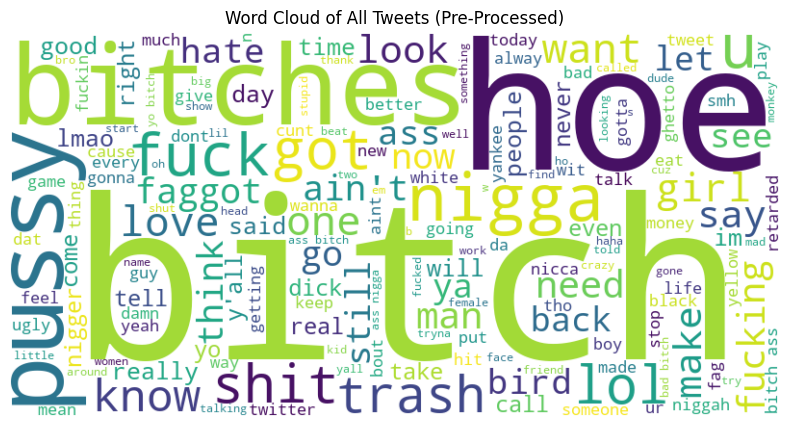

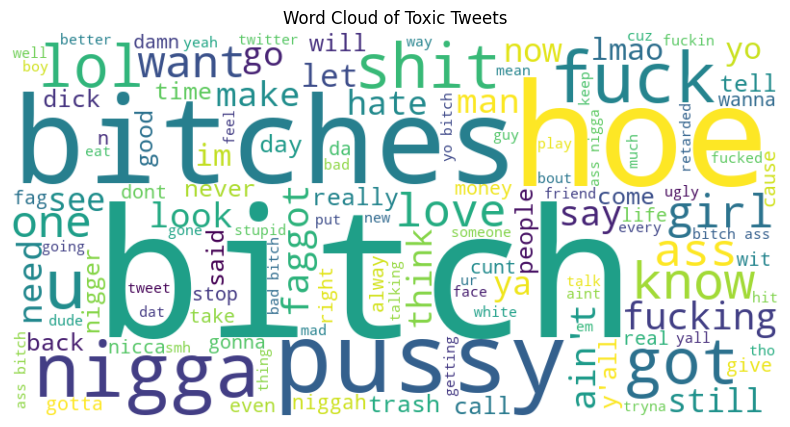

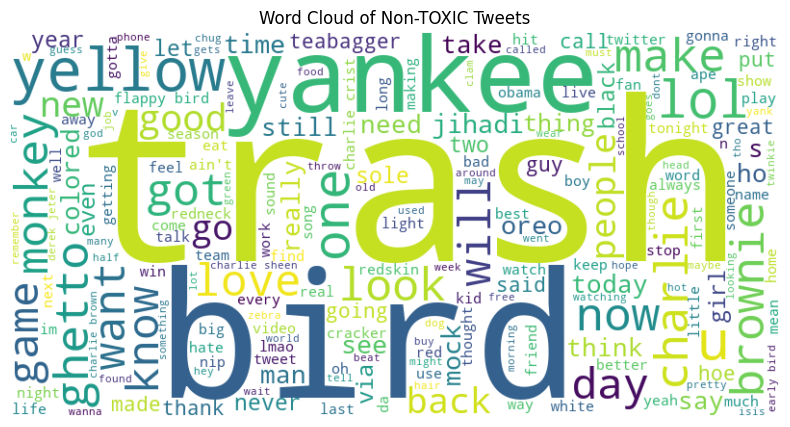

In [49]:
# Making wordclouds for all words
all_text = ' '.join(df['light_cleaned_tweet'])

wordcloud_all = WordCloud(
    width=800, height=400,
    background_color='white',
    min_font_size=10
).generate(all_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_all, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of All Tweets (Pre-Processed)')
plt.show()

# Making wordcloud for toxic texts
toxic_text = ' '.join(df[df['Toxicity'] == 1]['light_cleaned_tweet'])

wordcloud_toxic = WordCloud(
    width=800, height=400,
    background_color='white',
    min_font_size=10
).generate(toxic_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_toxic, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Toxic Tweets')
plt.show()

# Making wordcloud for non-toxic texts
neutral_text = ' '.join(df[df['Toxicity'] == 0]['light_cleaned_tweet'])

wordcloud_nontoxic = WordCloud(
    width=800, height=400,
    background_color='white',
    min_font_size=10
).generate(neutral_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_nontoxic, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Non-TOXIC Tweets')
plt.show()

# Train Test Validation Splitting

In [50]:
# Train test validation splitting
X = df['light_cleaned_tweet']
y = df['Toxicity']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

print("Train size:", len(X_train))
print("Validation size:", len(X_val))
print("Test size:", len(X_test))

Train size: 17348
Validation size: 3717
Test size: 3718


# Augmentation

In [51]:
train_df = pd.DataFrame({'text': X_train, 'label': y_train})

# Isolate the minority class from the training set ONLY
minority_train = train_df[train_df['label'] == 0]

aug = naw.SynonymAug(aug_src='wordnet')
augmented_texts = [aug.augment(text)[0] for text in minority_train['text']]

# Create the augmented samples dataframe
df_augmented_samples = pd.DataFrame({
    'text': augmented_texts,
    'label': 0 
})

# Combine back into the final training set
train_df_final = pd.concat([train_df, df_augmented_samples], axis=0).reset_index(drop=True)

# Update your training variables
X_train = train_df_final['text']
y_train = train_df_final['label']

print(f"Final Augmented Train size: {len(X_train)}")
print(f"Validation and Test sizes (Untouched): {len(X_val)}, {len(X_test)}")

Final Augmented Train size: 20262
Validation and Test sizes (Untouched): 3717, 3718


--- Training Set Distribution After Augmentation ---
label
1    71.236798
0    28.763202
Name: proportion, dtype: float64


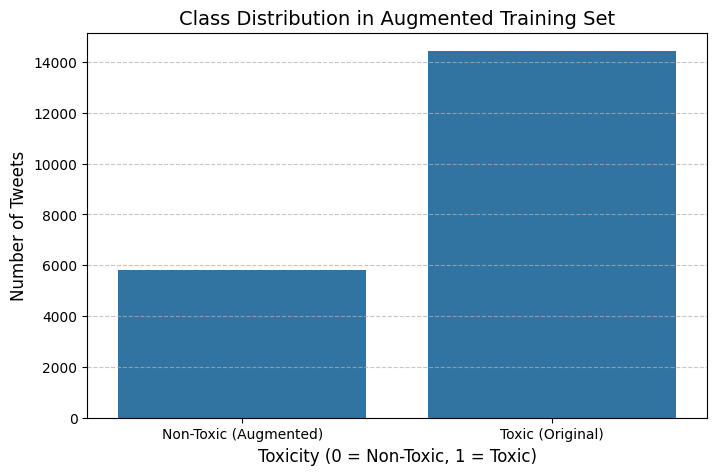

In [52]:
print("--- Training Set Distribution After Augmentation ---")
print(y_train.value_counts(normalize=True) * 100)

plt.figure(figsize=(8, 5))
sns.countplot(x=y_train)

plt.title('Class Distribution in Augmented Training Set', fontsize=14)
plt.xlabel('Toxicity (0 = Non-Toxic, 1 = Toxic)', fontsize=12)
plt.ylabel('Number of Tweets', fontsize=12)
plt.xticks(ticks=[0, 1], labels=['Non-Toxic (Augmented)', 'Toxic (Original)'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Preprocessing

In [53]:
# Preprocessing function for Logistic regression
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_lr(text):
    text = text.translate(str.maketrans("", "", string.punctuation))
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words and len(w) > 2]
    return " ".join(tokens)

In [54]:
# Preprocessing function for RoBERTa
def preprocess_roberta(text):
    return text.strip()

In [55]:
# Applying the preprocessing
X_train_lr = X_train.apply(preprocess_lr)
X_val_lr   = X_val.apply(preprocess_lr)
X_test_lr  = X_test.apply(preprocess_lr)

X_train_rob = X_train.apply(preprocess_roberta)
X_val_rob   = X_val.apply(preprocess_roberta)
X_test_rob  = X_test.apply(preprocess_roberta)

# Tokenization

In [56]:
# Logistic Regression Tokenization Using TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train_lr)
X_val_tfidf = tfidf.transform(X_val_lr)
X_test_tfidf  = tfidf.transform(X_test_lr)

# Model Training

In [115]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, C=0.1)
lr.fit(X_train_tfidf, y_train)

LogisticRegression(C=0.1, max_iter=1000)

In [116]:
y_val_pred = lr.predict(X_val_tfidf)
y_val_prob = lr.predict_proba(X_val_tfidf)[:, 1]

# Classification report of Logistic Regresion Model with validation data
print("Initial LR validation scores")
print(classification_report(y_val, y_val_pred))

Initial LR validation scores
              precision    recall  f1-score   support

           0       0.86      0.70      0.77       624
           1       0.94      0.98      0.96      3093

    accuracy                           0.93      3717
   macro avg       0.90      0.84      0.86      3717
weighted avg       0.93      0.93      0.93      3717



In [117]:
# Classification report of Logistic Regresion Model
y_test_pred = (lr.predict_proba(X_test_tfidf)[:,1] >= 0.35).astype(int)
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.93      0.25      0.40       625
           1       0.87      1.00      0.93      3093

    accuracy                           0.87      3718
   macro avg       0.90      0.63      0.66      3718
weighted avg       0.88      0.87      0.84      3718



In [118]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(class_weight='balanced', max_iter=1000, C=10)
lr.fit(X_train_tfidf, y_train)

LogisticRegression(C=10, class_weight='balanced', max_iter=1000)

In [123]:
y_val_pred = lr.predict(X_val_tfidf)
y_val_prob = lr.predict_proba(X_val_tfidf)[:, 1]

# Classification report of Logistic Regresion Model with validation data
print("Optimized LR validation scores")
print(classification_report(y_val, y_val_pred))

Optimized LR validation scores
              precision    recall  f1-score   support

           0       0.79      0.93      0.85       624
           1       0.98      0.95      0.97      3093

    accuracy                           0.95      3717
   macro avg       0.89      0.94      0.91      3717
weighted avg       0.95      0.95      0.95      3717



In [124]:
# Classification report of Logistic Regresion Model with 0.35 threshold

threshold = 0.35
y_val_custom = (y_val_prob >= threshold).astype(int)

print("LR with 0.35 threshold")
print(classification_report(y_val, y_val_custom))

LR with 0.35 threshold
              precision    recall  f1-score   support

           0       0.82      0.89      0.86       624
           1       0.98      0.96      0.97      3093

    accuracy                           0.95      3717
   macro avg       0.90      0.93      0.91      3717
weighted avg       0.95      0.95      0.95      3717



In [125]:
# Classification report of Logistic Regresion Model with 0.65 threshold

threshold = 0.65
y_val_custom = (y_val_prob >= threshold).astype(int)

print("LR with 0.65 threshold")
print(classification_report(y_val, y_val_custom))

LR with 0.65 threshold
              precision    recall  f1-score   support

           0       0.74      0.96      0.83       624
           1       0.99      0.93      0.96      3093

    accuracy                           0.94      3717
   macro avg       0.87      0.94      0.90      3717
weighted avg       0.95      0.94      0.94      3717



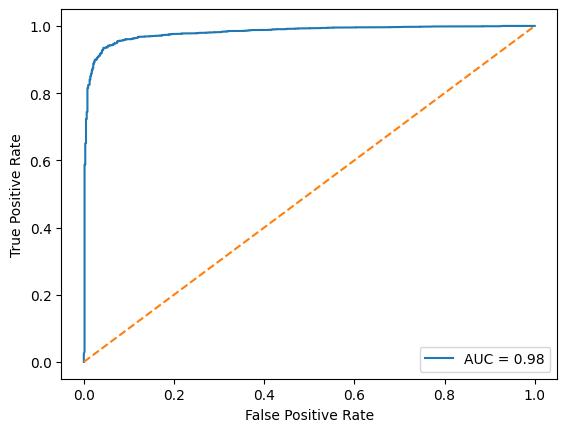

In [122]:
fpr, tpr, _ = roc_curve(y_val, y_val_prob)
auc = roc_auc_score(y_val, y_val_prob)

plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


In [126]:
# Classification report of Logistic Regresion Model
y_test_pred = (lr.predict_proba(X_test_tfidf)[:,1] >= 0.35).astype(int)
print(classification_report(y_test, y_test_pred))


              precision    recall  f1-score   support

           0       0.83      0.87      0.85       625
           1       0.97      0.96      0.97      3093

    accuracy                           0.95      3718
   macro avg       0.90      0.92      0.91      3718
weighted avg       0.95      0.95      0.95      3718



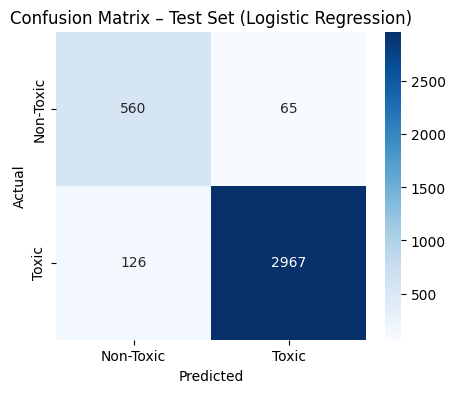

In [33]:
threshold = 0.35
y_test_prob = lr.predict_proba(X_test_tfidf)[:, 1]
y_test_pred = (y_test_prob >= threshold).astype(int)

# Confusion matrix
cm_test = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Toxic', 'Toxic'],
            yticklabels=['Non-Toxic', 'Toxic'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – Test Set (Logistic Regression)")
plt.show()


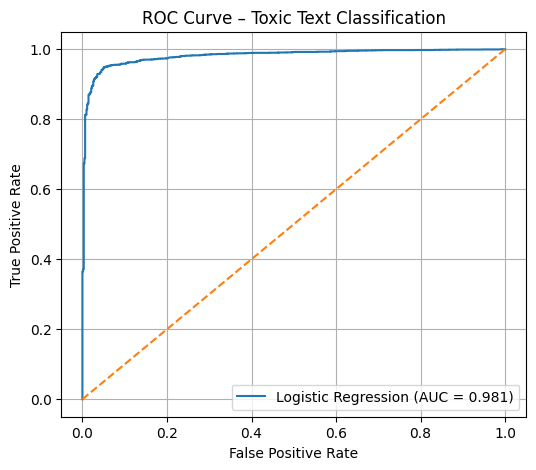

ROC AUC Score: 0.981213061752344


In [34]:
y_test_proba = lr.predict_proba(X_test_tfidf)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
auc_score = roc_auc_score(y_test, y_test_proba)

# Plot ROC curve
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Toxic Text Classification")
plt.legend()
plt.grid(True)
plt.show()

print("ROC AUC Score:", auc_score)


In [35]:
def predict_toxicity_lr(text):
    text = light_clean_noise(text)
    text = preprocess_lr(text)
    vec = tfidf.transform([text])
    prob = lr.predict_proba(vec)[0][1]
    pred = int(prob >= 0.35)
    return pred, prob


In [36]:
predict_toxicity_lr("I hate you")

(1, np.float64(0.6901259724786825))

In [37]:
import joblib

joblib.dump(lr, "logistic_regression_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

# RoBERTa Finetuning

Imports for RoBERTa

In [1]:
!pip install tf-keras
import torch
import numpy as np
from transformers import (
    RobertaTokenizer,
    RobertaForSequenceClassification,
    Trainer,
    TrainingArguments
)
from datasets import Dataset
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.utils.class_weight import compute_class_weight
from torch.nn import CrossEntropyLoss

C:\Users\acer\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [15]:
tokenizer = RobertaTokenizer.from_pretrained("roberta-base")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

In [16]:
train_df = Dataset.from_dict({
    "text": list(X_train_rob),
    "label": list(y_train)
})

val_df = Dataset.from_dict({
    "text": list(X_val_rob),
    "label": list(y_val)
})

test_df = Dataset.from_dict({
    "text": list(X_test_rob),
    "label": list(y_test)
})


In [17]:
def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )
train_df = train_df.map(tokenize_batch, batched=True)
val_df   = val_df.map(tokenize_batch, batched=True)
test_df  = test_df.map(tokenize_batch, batched=True)

Map:   0%|          | 0/20262 [00:00<?, ? examples/s]

Map:   0%|          | 0/4342 [00:00<?, ? examples/s]

Map:   0%|          | 0/4342 [00:00<?, ? examples/s]

In [ ]:
print(train_df)

Dataset({
    features: ['text', 'label', 'input_ids', 'attention_mask'],
    num_rows: 20262
})


In [18]:
train_df.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
val_df.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
test_df.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])


In [ ]:
model_1 = RobertaForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=2
)


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
for name, param in model_1.named_parameters():
    if not any(layer in name for layer in ["layer.10", "layer.11", "classifier"]):
        param.requires_grad = False


In [ ]:
training_args= TrainingArguments(
    output_dir="./weak_results",
    eval_strategy="epoch",
    save_strategy="no",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    report_to="none"
)


In [24]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds = np.argmax(pred.predictions, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary"
    )
    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }


In [ ]:
trainer_weak = Trainer(
    model=model_1,
    args=training_args,
    train_dataset=train_df,
    eval_dataset=val_df,
    compute_metrics=compute_metrics,
    tokenizer=tokenizer
)


C:\Users\acer\AppData\Local\Temp\ipykernel_67992\2838741438.py:3: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer_weak = Trainer(


In [ ]:
trainer_weak.train()


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.167300,0.173588,0.938508,0.938547,0.977692,0.957720
2,0.147000,0.150054,0.952556,0.965195,0.968316,0.966753
3,0.120900,0.159889,0.953017,0.964918,0.969285,0.967097


TrainOutput(global_step=3801, training_loss=0.16053171817706277, metrics={'train_runtime': 435.9508, 'train_samples_per_second': 139.433, 'train_steps_per_second': 8.719, 'total_flos': 3998367152778240.0, 'train_loss': 0.16053171817706277, 'epoch': 3.0})

In [ ]:
trainer_weak.evaluate(test_df)

{'eval_loss': 0.13843989372253418,
 'eval_accuracy': 0.9594656840165822,
 'eval_precision': 0.9730781706130393,
 'eval_recall': 0.9699321047526673,
 'eval_f1': 0.9715025906735751,
 'eval_runtime': 18.0781,
 'eval_samples_per_second': 240.18,
 'eval_steps_per_second': 15.046,
 'epoch': 3.0}

In [19]:
model= RobertaForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=2
)


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [20]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0,1]),
    y=y_train
)

class_weights = torch.tensor(class_weights, dtype=torch.float)


In [21]:
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fn = CrossEntropyLoss(weight=class_weights.to(model.device))
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss


In [22]:
training_args = TrainingArguments(
    output_dir="./final_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=1e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=4,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    optim="adamw_torch",
    report_to="none"
)


In [25]:
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_df,
    eval_dataset=val_df,
    compute_metrics=compute_metrics,
    processing_class=tokenizer
)

trainer.train()


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.167900,0.234169,0.957623,0.964252,0.976722,0.970447
2,0.124300,0.202790,0.966375,0.974557,0.978338,0.976444
3,0.102600,0.215148,0.963842,0.969010,0.980601,0.974771
4,0.064700,0.240283,0.964072,0.969920,0.979955,0.974912


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


TrainOutput(global_step=5068, training_loss=0.1253015965387966, metrics={'train_runtime': 1057.4743, 'train_samples_per_second': 76.681, 'train_steps_per_second': 4.793, 'total_flos': 5331156203704320.0, 'train_loss': 0.1253015965387966, 'epoch': 4.0})

In [26]:
trainer.evaluate(test_df)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


{'eval_loss': 0.16642329096794128,
 'eval_accuracy': 0.966835559649931,
 'eval_precision': 0.9773389446422791,
 'eval_recall': 0.9760750080827676,
 'eval_f1': 0.9767065674538984,
 'eval_runtime': 5.2407,
 'eval_samples_per_second': 830.431,
 'eval_steps_per_second': 51.902,
 'epoch': 4.0}

In [27]:
from google.colab import drive
drive.mount('/content/drive')

FINAL_PATH = "/content/drive/MyDrive/FYP/models/roberta_toxic_final"

model.to("cpu")
model.save_pretrained(FINAL_PATH)
tokenizer.save_pretrained(FINAL_PATH)

print("Final model saved successfully.")


Mounted at /content/drive
Final model saved successfully.


In [29]:
import torch
import torch_xla.core.xla_model as xm

device = xm.xla_device()

model.to(device)
model.eval()


/tmp/ipython-input-427604144.py:4: DeprecationWarning: Use torch_xla.device instead
  device = xm.xla_device()


RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
         

In [30]:
test_results = trainer.predict(test_df)

print({
    "Accuracy": test_results.metrics["test_accuracy"],
    "Precision": test_results.metrics["test_precision"],
    "Recall": test_results.metrics["test_recall"],
    "F1": test_results.metrics["test_f1"]
})


{'Accuracy': 0.966835559649931, 'Precision': 0.9773389446422791, 'Recall': 0.9760750080827676, 'F1': 0.9767065674538984}


In [31]:
def predict_toxicity_roberta_tpu(text):
    text = preprocess_roberta(text)

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    # Move ALL inputs to TPU
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=1)
        pred = torch.argmax(probs, dim=1)

    # Move results back to CPU safely
    return {
        "label": "Toxic" if pred.cpu().item() == 1 else "Non-Toxic",
        "confidence": probs.cpu()[0][pred.cpu().item()].item()
    }


In [34]:
predict_toxicity_roberta_tpu("i like you")


{'label': 'Non-Toxic', 'confidence': 0.9645328521728516}

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


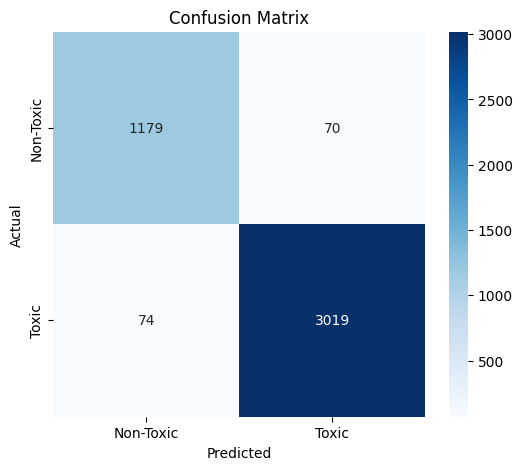

In [37]:
test_results = trainer.predict(test_df)
y_true = test_results.label_ids
preds_tensor = torch.from_numpy(test_results.predictions).to(device)
y_probs = torch.nn.functional.softmax(preds_tensor, dim=-1)[:, 1].cpu().numpy()
y_pred = np.argmax(test_results.predictions, axis=-1)


# confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Non-Toxic", "Toxic"], yticklabels=["Non-Toxic", "Toxic"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

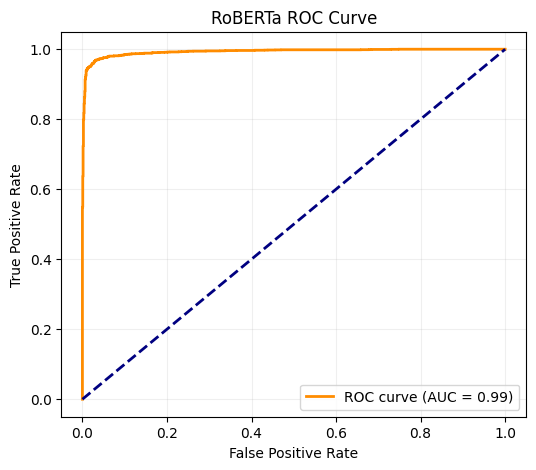

In [38]:
from sklearn.metrics import roc_curve, auc as calculate_auc

fpr, tpr, thresholds = roc_curve(y_true, y_probs)

roc_auc_value = calculate_auc(fpr, tpr)

# Plotting
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc_value:.2f})")
plt.plot([0,1], [0,1], color="navy", lw=2, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("RoBERTa ROC Curve")
plt.legend(loc="lower right")
plt.grid(alpha=0.2)
plt.show()

In [39]:
# Classification report of RoBERTa
print(classification_report(y_true, y_pred, target_names=["Non-Toxic","Toxic"]))

              precision    recall  f1-score   support

   Non-Toxic       0.94      0.94      0.94      1249
       Toxic       0.98      0.98      0.98      3093

    accuracy                           0.97      4342
   macro avg       0.96      0.96      0.96      4342
weighted avg       0.97      0.97      0.97      4342

